In [6]:
#Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#  Load dataset
df = pd.read_csv('/content/Covid_19_Clean_Complete (2).csv')

In [8]:
# View dataset
df


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [9]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [10]:
df.tail()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [12]:
# Shape of the dataset
df.shape

(49068, 10)

In [13]:
# Rename columns
# Province/State --> State
# Country/Region --> Country
df.rename(
    columns={
        'Province/State': 'State',
        'Country/Region': 'Country'
    },
    inplace=True
)

In [14]:
# Get the value count of the Date column
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [15]:
# Check maximum date
df['Date'].max()

'2020-07-27'

In [16]:
# Get all records for 27th July 2020
top = df[df['Date'] == '2020-07-27']
top


,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [17]:
# Country-wise Confirmed, Deaths, Recovered and Active cases
country_wise = top.groupby(
    by='Country'
)[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

country_wise

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


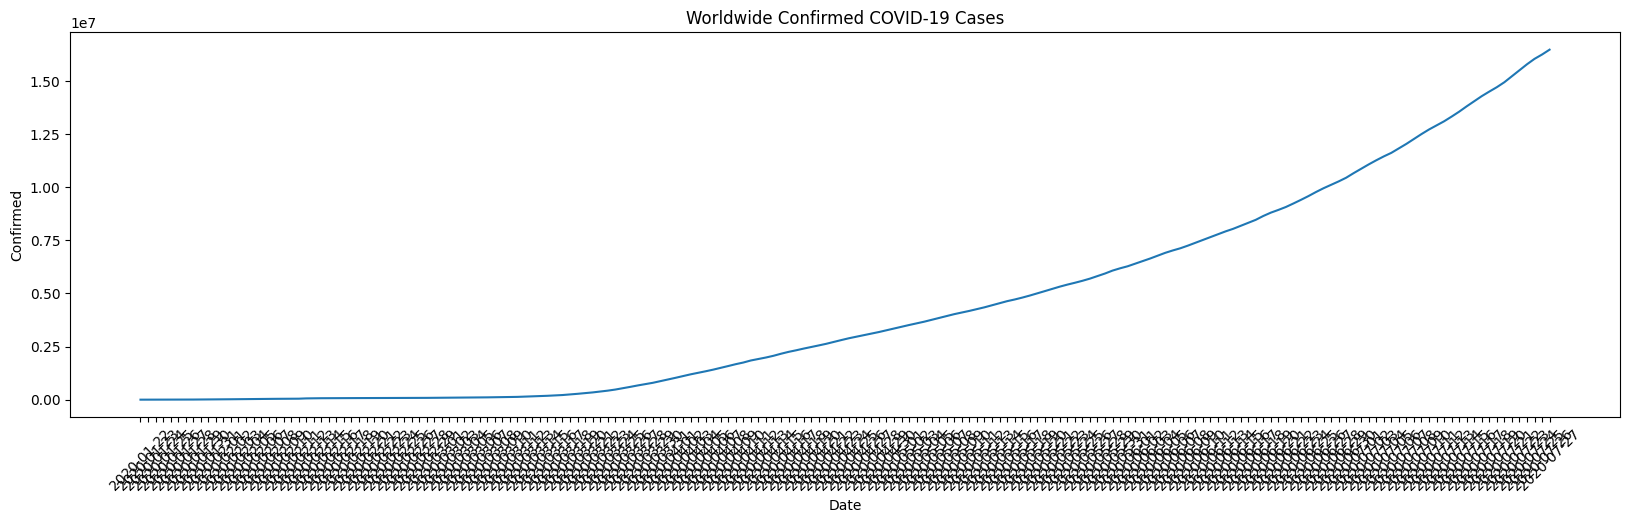

In [18]:
#  Confirmed cases over time
confirmed = df.groupby(
    by='Date'
)['Confirmed'].sum().reset_index()

plt.figure(figsize=(20, 5))
sns.lineplot(data=confirmed, x='Date', y='Confirmed')
plt.xticks(rotation=45)
plt.title('Worldwide Confirmed COVID-19 Cases')
plt.show()

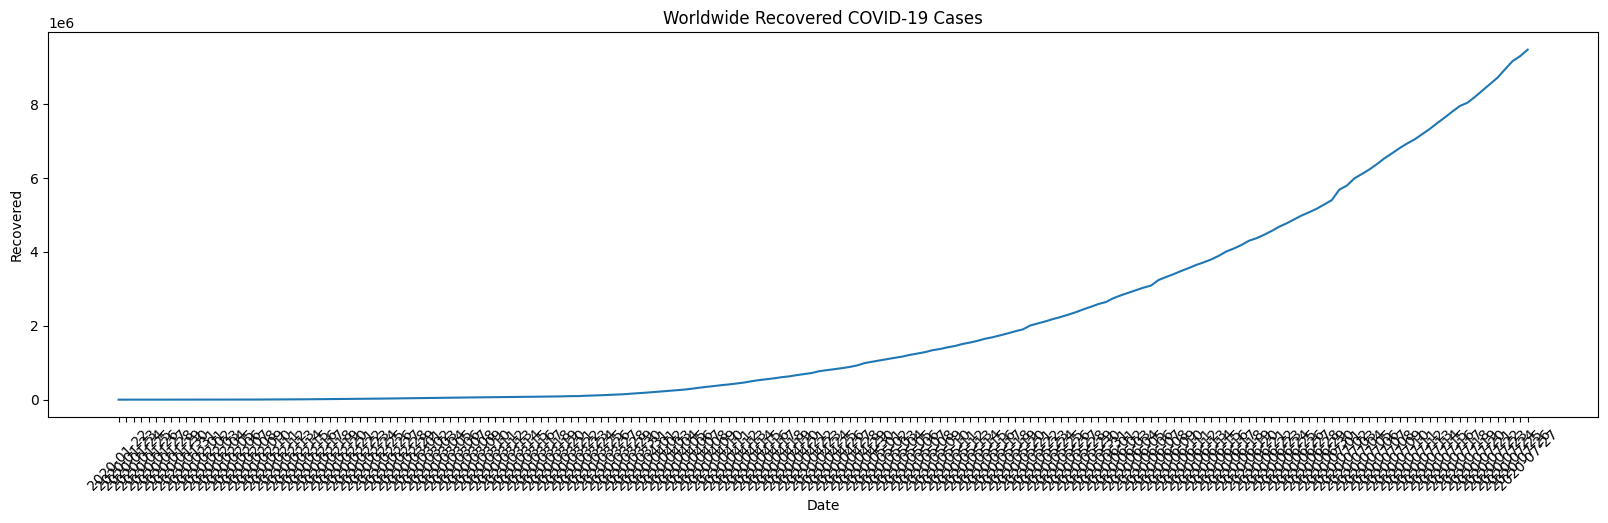

In [19]:
# Recovered cases over time
recovered = df.groupby(
    by='Date'
)['Recovered'].sum().reset_index()

recovered

plt.figure(figsize=(20, 5))
sns.lineplot(data=recovered, x='Date', y='Recovered')
plt.xticks(rotation=45)
plt.title('Worldwide Recovered COVID-19 Cases')
plt.show()

In [20]:
# 5. Model Building - Prophet

# Prophet does not require the data to be stationary.
# It can also handle missing data reasonably well.

In [21]:
from prophet import Prophet

# Prepare data for Prophet
confirmed_data = df.groupby(
    'Date'
)[['Confirmed']].sum().reset_index()

In [22]:
# Prophet requires columns:
# ds = date
# y  = target value
prophet_data = confirmed_data.rename(
    columns={
        'Date': 'ds',
        'Confirmed': 'y'
    }
)


In [23]:
# Make sure Date is in datetime format
prophet_data['ds'] = pd.to_datetime(prophet_data['ds'])

In [24]:
# Create and train model
model = Prophet()
model.fit(prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [25]:
# Create future dates for 7 days
future = model.make_future_dataframe(periods=7)
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [26]:
# Make predictions
forecast = model.predict(future)

In [27]:
# Display forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,1.632021e+07,1.620871e+07,1.642280e+07
189,2020-07-29,1.652998e+07,1.643361e+07,1.664003e+07
190,2020-07-30,1.674392e+07,1.664043e+07,1.684628e+07
191,2020-07-31,1.695911e+07,1.685110e+07,1.706800e+07
192,2020-08-01,1.716677e+07,1.705641e+07,1.727537e+07
193,2020-08-02,1.736430e+07,1.724736e+07,1.748136e+07
194,2020-08-03,1.755889e+07,1.743665e+07,1.767884e+07


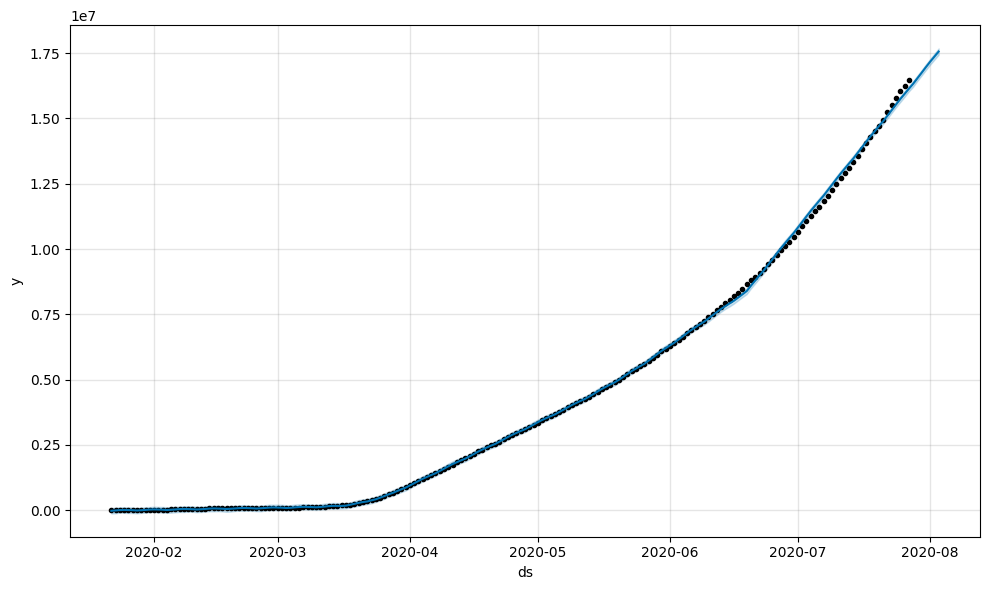

In [28]:
# Plot forecast
model.plot(forecast)
plt.show()

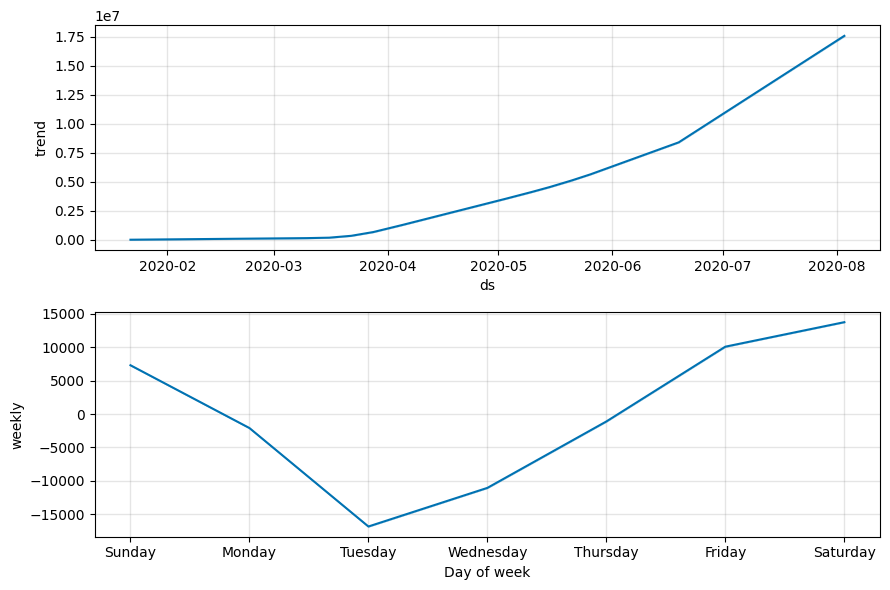

In [29]:
# Plot forecast components
model.plot_components(forecast)
plt.show()


In [30]:
# Model Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [31]:
# Use the last 7 actual days as test data
test = prophet_data.tail(7).copy()

In [32]:
# Get corresponding predictions
forecast_test = forecast[
    forecast['ds'].isin(test['ds'])
][['ds', 'yhat']]

In [33]:
# Merge actual and predicted values
evaluation = test.merge(
    forecast_test,
    on='ds'
)

In [34]:
# Calculate MAE
mae = mean_absolute_error(
    evaluation['y'],
    evaluation['yhat']
)

In [35]:
# Calculate MSE
mse = mean_squared_error(
    evaluation['y'],
    evaluation['yhat']
)

In [36]:
# Calculate RMSE
rmse = np.sqrt(mse)



In [51]:

# Calculate MAPE
mape = np.mean(
    np.abs(
        (evaluation['y'] - evaluation['yhat']) /
        evaluation['y']
    )
) * 100

In [38]:
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape, "%")

MAE  : 229824.70608846977
MSE  : 63032028454.689995
RMSE : 251061.80206214165
MAPE : 1.4398201898124263 %


In [40]:
# PROPER TRAIN-TEST SPLIT

# Make sure data is sorted by date
prophet_data = prophet_data.sort_values('ds').reset_index(drop=True)

# Last 7 days = test data
train = prophet_data.iloc[:-7]
test = prophet_data.iloc[-7:]

print("Training data:")
print(train.tail())

print("\nTest data:")
print(test)

Training data:
            ds         y
176 2020-07-16  13812525
177 2020-07-17  14054563
178 2020-07-18  14292198
179 2020-07-19  14506845
180 2020-07-20  14713623

Test data:
            ds         y
181 2020-07-21  14947078
182 2020-07-22  15227725
183 2020-07-23  15510481
184 2020-07-24  15791645
185 2020-07-25  16047190
186 2020-07-26  16251796
187 2020-07-27  16480485


In [41]:
# Create a new Prophet model
model_test = Prophet()

# Train ONLY on training data
model_test.fit(train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [42]:
# Create future dates for the test period
future_test = model_test.make_future_dataframe(
    periods=7,
    freq='D'
)

In [46]:

# Make predictions
forecast_test = model_test.predict(future_test)

In [47]:
# Get predictions only for the test dates
forecast_test = forecast_test[
    forecast_test['ds'].isin(test['ds'])
][['ds', 'yhat']]

In [48]:
# Combine actual and predicted values
results = test.merge(
    forecast_test,
    on='ds'
)

print("\nActual vs Predicted:")
print(results[['ds', 'y', 'yhat']])


Actual vs Predicted:
          ds         y          yhat
0 2020-07-21  14947078  1.454548e+07
1 2020-07-22  15227725  1.473505e+07
2 2020-07-23  15510481  1.492831e+07
3 2020-07-24  15791645  1.512193e+07
4 2020-07-25  16047190  1.531174e+07
5 2020-07-26  16251796  1.549085e+07
6 2020-07-27  16480485  1.566666e+07


In [49]:
# Calculate MAE
mae = mean_absolute_error(
    results['y'],
    results['yhat']
)

# Calculate MSE
mse = mean_squared_error(
    results['y'],
    results['yhat']
)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAPE
mape = np.mean(
    np.abs(
        (results['y'] - results['yhat']) /
        results['y']
    )
) * 100


# Print results
print("\nMODEL PERFORMANCE")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape, "%")






MODEL PERFORMANCE
-------------------------
MAE  : 636626.4353600045
MSE  : 424813887171.78766
RMSE : 651777.4828664977
MAPE : 4.017135033490407 %


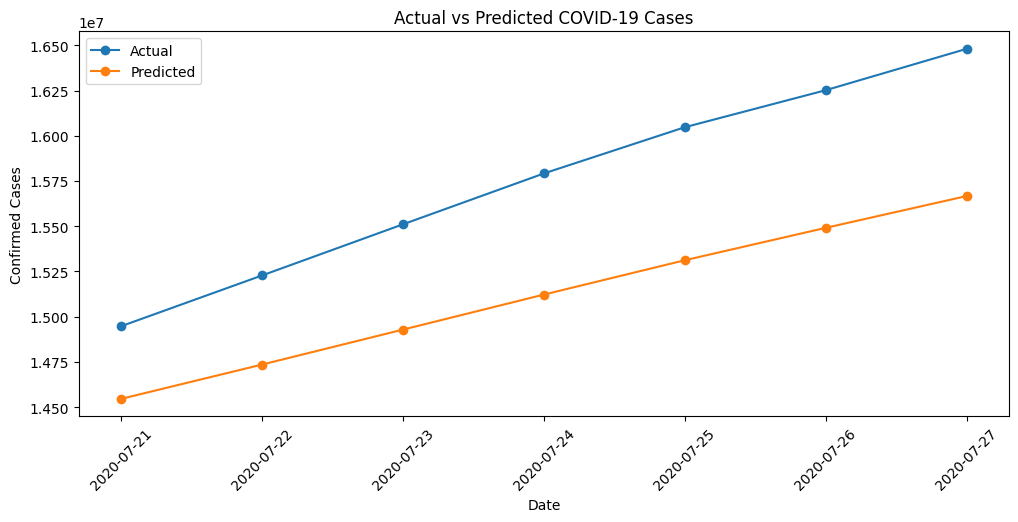

In [50]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.plot(
    results['ds'],
    results['y'],
    marker='o',
    label='Actual'
)

plt.plot(
    results['ds'],
    results['yhat'],
    marker='o',
    label='Predicted'
)

plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.title('Actual vs Predicted COVID-19 Cases')
plt.legend()
plt.xticks(rotation=45)
plt.show()


## Final Interpretation

I used the **Prophet model** to predict COVID-19 cases.

I tested the model on the last **7 days** of data. The model gave a **MAPE of 4.02%**, which means the predictions were fairly close to the actual values.

The graph shows that the model followed the overall trend, but it predicted fewer cases than the actual number during the last few days.

### Final Conclusion

Overall, the Prophet model was able to understand the general trend and make fairly good short-term predictions.

This project helped me learn **data cleaning, data analysis, forecasting, visualization, and model evaluation**.

However, COVID-19 cases can change because of many outside factors, so the model may not always give accurate predictions.

**Final conclusion:** The model is useful for **short-term forecasting**, but it should not be used as a perfect long-term prediction.
